<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/largest_islands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World's largest islands

This dataset `largest-islands.csv` contains information about the 100 largest islands in the world. The unit for the `area` column is km2.

In [15]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'largest-islands.csv'.

from google.colab import files
uploaded = files.upload()

Saving largest-islands.csv to largest-islands (1).csv


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('largest-islands.csv')
df.head()

,region,island,area,countries,climate,rank
0,Africa,Madagascar,591896,Madagascar,tropics,4
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France",temperate,91
2,Asia,Sumba,11153,Indonesia,tropics,65
3,Asia,Hainan,34300,China,tropics,37
4,Asia,Taiwan,36198,Taiwan,tropics,36


### Project Ideas

- What are the 10 largest islands in the tropics?

- What are the largest islands in each `region`?

- Create a line graph with `area` on the y-axis and `rank` on the x-axis. The data should be ordered by `rank`, from largest to smallest.

- What islands are composed of multiple countries?
	- Hint: try `countries.str.contains(",")`

In [17]:
# What are the 10 largest islands in the tropics?
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el dataset
df = pd.read_csv('largest-islands.csv')

# Filtramos por clima 'tropics' y ordenamos por área de mayor a menor
top_10_tropics = df[df['climate'] == 'tropics'].sort_values(by='area', ascending=False).head(10)
print("10 islas más grandes en el trópico:")
print(top_10_tropics[['island', 'area', 'region']])

10 islas más grandes en el trópico:
        island    area         region
86  New Guinea  821400        Oceania
23      Borneo  755000           Asia
0   Madagascar  591896         Africa
28     Sumatra  480793           Asia
22    Sulawesi  188522           Asia
21        Java  129438           Asia
80        Cuba  109884  North America
26       Luzon  104688           Asia
14    Mindanao   94630           Asia
73  Hispaniola   76192  North America


In [18]:
# What are the largest islands in each region?

# Agrupamos por región y obtenemos el índice del valor máximo de área
largest_by_region = df.loc[df.groupby('region')['area'].idxmax()]
print("\nIsla más grande por cada región:")
print(largest_by_region[['region', 'island', 'area']])


Isla más grande por cada región:
           region                           island     area
0          Africa                       Madagascar   591896
1       Antarctic                        Kerguelen     6200
23           Asia                           Borneo   755000
35        Eurasia                         Sakhalin    76400
41         Europe                        Greenland  2166086
75  North America                    Baffin Island   507451
86        Oceania                       New Guinea   821400
98  South America  Isla Grande de Tierra del Fuego    47992



Gráfico guardado como 'islands_rank_area.png'


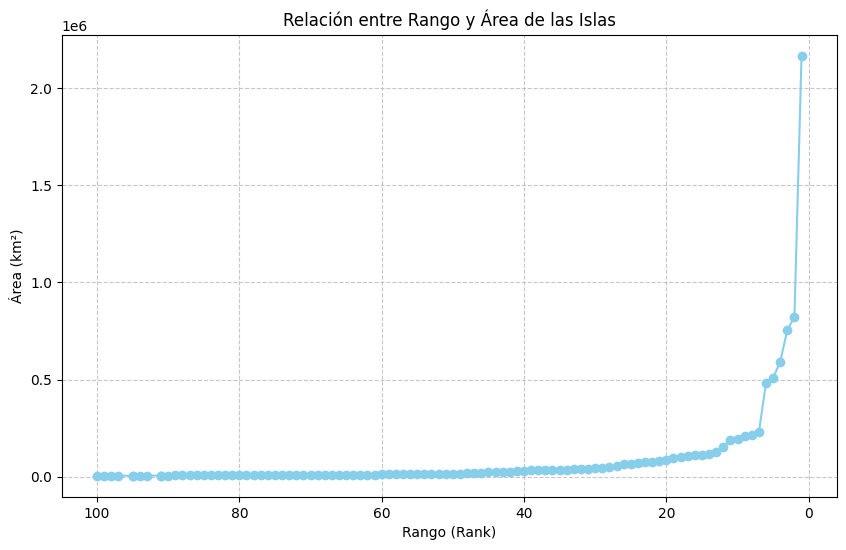

In [19]:
# Create a line graph with area on the y-axis and rank on the x-axis. The data should be ordered by rank, from largest to smallest.

# Ordenamos por rank para asegurar que el gráfico fluya correctamente
df_sorted = df.sort_values(by='rank')

plt.figure(figsize=(10, 6))
plt.plot(df_sorted['rank'], df_sorted['area'], marker='o', color='skyblue', linestyle='-')
plt.title('Relación entre Rango y Área de las Islas')
plt.xlabel('Rango (Rank)')
plt.ylabel('Área (km²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().invert_xaxis()  # Opcional: para mostrar del rango 1 al 100 de izquierda a derecha
plt.savefig('islands_rank_area.png')
print("\nGráfico guardado como 'islands_rank_area.png'")

In [20]:
# What islands are composed of multiple countries? Hint: try countries.str.contains(",")

# Usamos el truco de buscar la coma en la columna 'countries'
multiple_countries = df[df['countries'].str.contains(",", na=False)]
print("\nIslas con múltiples países:")
print(multiple_countries[['island', 'countries']])


Islas con múltiples países:
                             island                    countries
1                         Kerguelen      Antarctic Lands, France
23                           Borneo  Indonesia, Malaysia, Brunei
45                          Ireland      Ireland, United Kingdom
50                           Cyprus       Cyprus, United Kingdom
73                       Hispaniola    Dominican Republic, Haiti
86                       New Guinea  Papua New Guinea, Indonesia
98  Isla Grande de Tierra del Fuego             Chile, Argentina
